# Task 2: Brain Tumor MRI Classification Using CNN and Transfer Learning

This notebook implements an end-to-end deep learning pipeline for classifying brain MRI images into four categories: glioma tumor, meningioma tumor, pituitary tumor, and normal brain scans.

The notebook follows the assessment requirements for the Vision Task and the project proposal. It includes dataset analysis, preprocessing, augmentation, baseline CNN, deeper CNN with regularization, optimizer comparison, ablation study, transfer learning using EfficientNetB3, evaluation metrics, ROC-AUC, Grad-CAM visualization, and final model comparison.

In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import time
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import EfficientNetB3

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import time
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import EfficientNetB3

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# 2. REPRODUCIBILITY AND HARDWARE CHECK
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices("GPU")) > 0)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU Available: True
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Dataset Path Setup

The dataset is stored in Google Drive. The code below mounts Google Drive and searches for the Brain Tumor Classification dataset folder. The dataset must contain two folders: `train` and `test`.

In [5]:
# ============================================================
# 3. MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ============================================================
# 4. SET DATASET PATH
# ============================================================

import os

DATASET_DIR = "/content/drive/MyDrive/Ai and Machine Learning/Brain Tumor Classifcation"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print("Dataset directory:", DATASET_DIR)
print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Train directory exists:", os.path.exists(TRAIN_DIR))
print("Test directory exists:", os.path.exists(TEST_DIR))

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError("Dataset folder not found. Please check DATASET_DIR path.")

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError("Train folder not found inside dataset folder.")

if not os.path.exists(TEST_DIR):
    raise FileNotError("Test folder not found inside dataset folder.")

print("\nTrain classes:")
print(os.listdir(TRAIN_DIR))

print("\nTest classes:")
print(os.listdir(TEST_DIR))

Dataset directory: /content/drive/MyDrive/Ai and Machine Learning/Brain Tumor Classifcation
Dataset exists: True
Train directory exists: True
Test directory exists: True

Train classes:
['pituitary_tumor', 'normal', 'meningioma_tumor', 'glioma_tumor']

Test classes:
['meningioma_tumor', 'glioma_tumor', 'normal', 'pituitary_tumor']


## Dataset Understanding

The dataset contains MRI brain scan images organized into class folders. The aim is to classify each MRI image into one of four classes. Before training the models, it is important to understand the number of images, class distribution, imbalance, and dataset structure.

In [7]:
# ============================================================
# 5. GET CLASS NAMES
# ============================================================

def get_class_names(directory):
    return sorted([
        folder for folder in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, folder))
    ])

class_names = get_class_names(TRAIN_DIR)
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
Number of classes: 4


In [8]:
# ============================================================
# 6. COUNT IMAGES BY CLASS
# ============================================================

def count_images_by_class(directory):
    rows = []

    for cls in get_class_names(directory):
        cls_path = os.path.join(directory, cls)

        count = len([
            file for file in os.listdir(cls_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ])

        rows.append({
            "Class": cls,
            "Image Count": count
        })

    return pd.DataFrame(rows)

train_count_df = count_images_by_class(TRAIN_DIR)
test_count_df = count_images_by_class(TEST_DIR)

print("Training distribution:")
display(train_count_df)

print("Testing distribution:")
display(test_count_df)

total_train = train_count_df["Image Count"].sum()
total_test = test_count_df["Image Count"].sum()
total_images = total_train + total_test

print("Total training images:", total_train)
print("Total testing images:", total_test)
print("Total images:", total_images)

Training distribution:


,Class,Image Count
0,glioma_tumor,713
1,meningioma_tumor,723
2,normal,343
3,pituitary_tumor,668


Testing distribution:


,Class,Image Count
0,glioma_tumor,181
1,meningioma_tumor,183
2,normal,88
3,pituitary_tumor,169


Total training images: 2447
Total testing images: 621
Total images: 3068


In [9]:
# ============================================================
# 7. COMBINED CLASS DISTRIBUTION TABLE
# ============================================================

combined_df = train_count_df.merge(
    test_count_df,
    on="Class",
    suffixes=(" Train", " Test")
)

combined_df["Total"] = combined_df["Image Count Train"] + combined_df["Image Count Test"]
combined_df["Train %"] = (
    combined_df["Image Count Train"] / combined_df["Image Count Train"].sum()
) * 100

display(combined_df)

,Class,Image Count Train,Image Count Test,Total,Train %
0,glioma_tumor,713,181,894,29.137720
1,meningioma_tumor,723,183,906,29.546383
2,normal,343,88,431,14.017164
3,pituitary_tumor,668,169,837,27.298733


## Corrupted Image Checking

Medical image datasets may contain corrupted or unreadable images. These images can stop the training process. Therefore, all training and testing images are checked using PIL before model training.

In [10]:
# ============================================================
# 8. CHECK AND REMOVE CORRUPTED IMAGES
# ============================================================

def remove_corrupted_images(directory):
    corrupted_files = []

    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                path = os.path.join(root, file)

                try:
                    with Image.open(path) as img:
                        img.verify()
                except Exception:
                    corrupted_files.append(path)

    print(f"Found {len(corrupted_files)} corrupted/unreadable images in {directory}")

    for path in corrupted_files:
        try:
            os.remove(path)
            print("Removed:", path)
        except Exception as e:
            print("Could not remove:", path, "| Error:", e)

    return corrupted_files

corrupted_train = remove_corrupted_images(TRAIN_DIR)
corrupted_test = remove_corrupted_images(TEST_DIR)

print("Total corrupted images removed:", len(corrupted_train) + len(corrupted_test))

Found 0 corrupted/unreadable images in /content/drive/MyDrive/Ai and Machine Learning/Brain Tumor Classifcation/train
Found 0 corrupted/unreadable images in /content/drive/MyDrive/Ai and Machine Learning/Brain Tumor Classifcation/test
Total corrupted images removed: 0


In [11]:
# ============================================================
# 9. RECOUNT AFTER CORRUPTED IMAGE REMOVAL
# ============================================================

train_count_df = count_images_by_class(TRAIN_DIR)
test_count_df = count_images_by_class(TEST_DIR)

print("Updated training distribution:")
display(train_count_df)

print("Updated testing distribution:")
display(test_count_df)

Updated training distribution:


,Class,Image Count
0,glioma_tumor,713
1,meningioma_tumor,723
2,normal,343
3,pituitary_tumor,668


Updated testing distribution:


,Class,Image Count
0,glioma_tumor,181
1,meningioma_tumor,183
2,normal,88
3,pituitary_tumor,169


## Class Distribution Visualization

Class distribution graphs help identify whether the dataset is balanced or imbalanced. In this dataset, the normal class has fewer images than the tumor classes, so class weights are used during training.

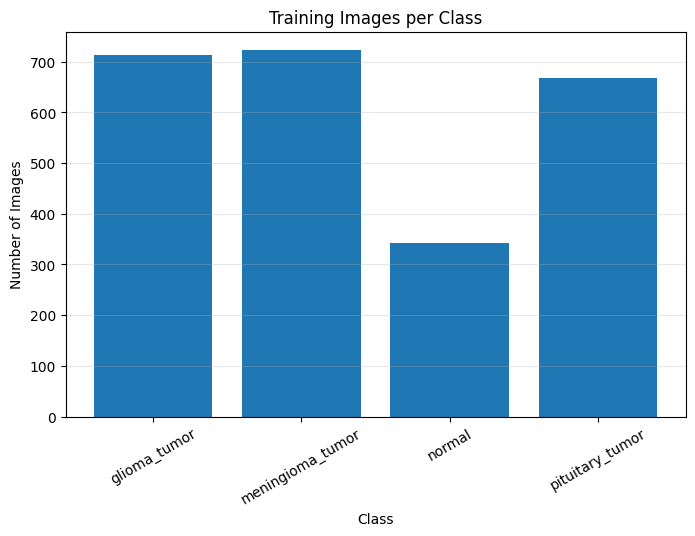

In [12]:
# ============================================================
# 10. VISUALIZE TRAINING CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(train_count_df["Class"], train_count_df["Image Count"])
plt.title("Training Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

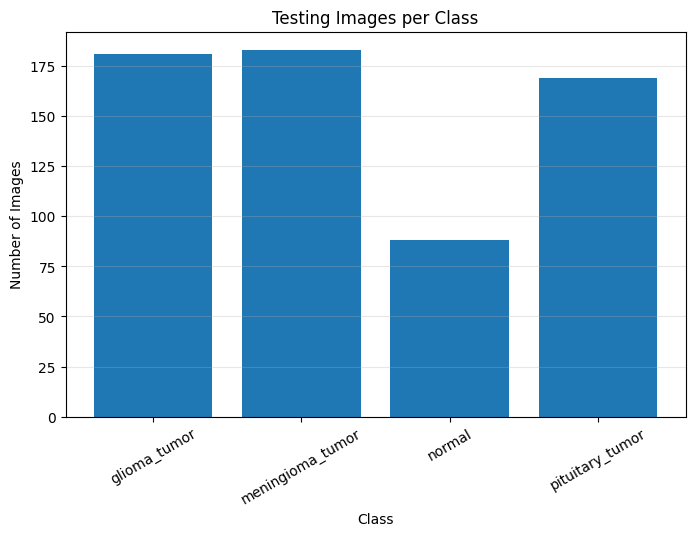

In [13]:
# ============================================================
# 11. VISUALIZE TESTING CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(test_count_df["Class"], test_count_df["Image Count"])
plt.title("Testing Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

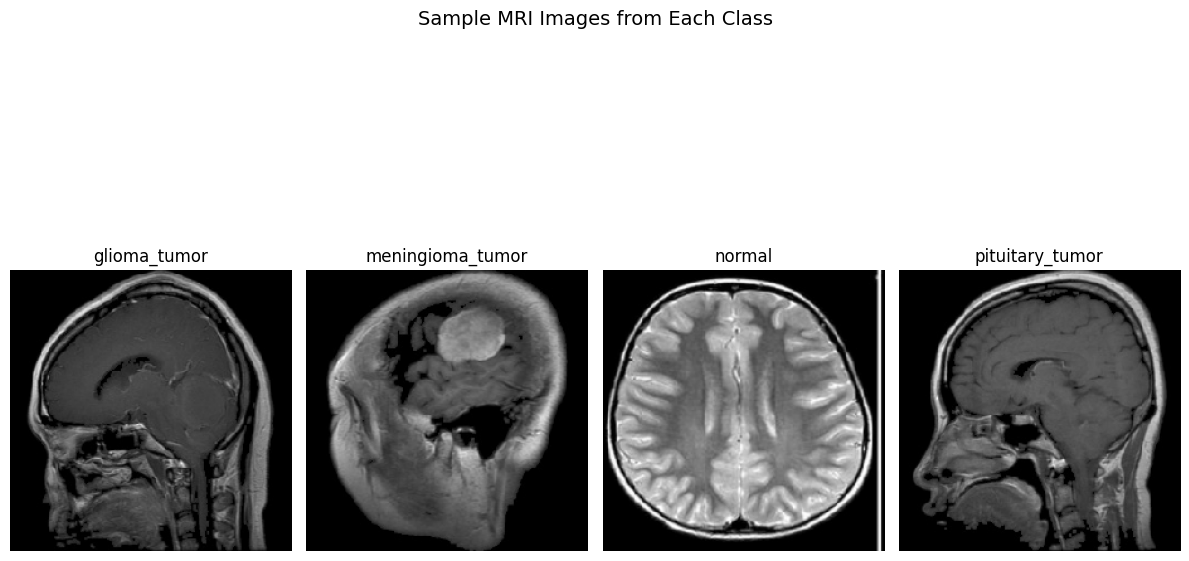

In [14]:
# ============================================================
# 12. SHOW SAMPLE IMAGES FROM EACH CLASS
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

plt.figure(figsize=(12, 8))

for i, cls in enumerate(class_names):
    cls_folder = os.path.join(TRAIN_DIR, cls)

    image_files = [
        file for file in os.listdir(cls_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    sample_file = random.choice(image_files)
    sample_path = os.path.join(cls_folder, sample_file)

    img = load_img(sample_path, target_size=IMG_SIZE)

    plt.subplot(1, num_classes, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample MRI Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

## Data Preprocessing and Augmentation

All images are resized to 224 × 224 pixels. For custom CNN models, pixel values are rescaled to the range [0, 1]. Data augmentation is applied to increase variation in the training data and reduce overfitting.

In [15]:
# ============================================================
# 13. DATA GENERATORS FOR CUSTOM CNN MODELS
# ============================================================

train_datagen_cnn = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.15,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode="nearest"
)

val_datagen_cnn = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.15
)

test_datagen_cnn = ImageDataGenerator(
    rescale=1.0 / 255.0
)

In [16]:
# ============================================================
# 14. CREATE CNN TRAIN, VALIDATION, AND TEST GENERATORS
# ============================================================

train_gen_cnn = train_datagen_cnn.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_gen_cnn = val_datagen_cnn.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

test_gen_cnn = test_datagen_cnn.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_indices = train_gen_cnn.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

print("Class indices:", class_indices)
print("Index to class:", idx_to_class)

Found 2082 images belonging to 4 classes.
Found 365 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}
Index to class: {0: 'glioma_tumor', 1: 'meningioma_tumor', 2: 'normal', 3: 'pituitary_tumor'}


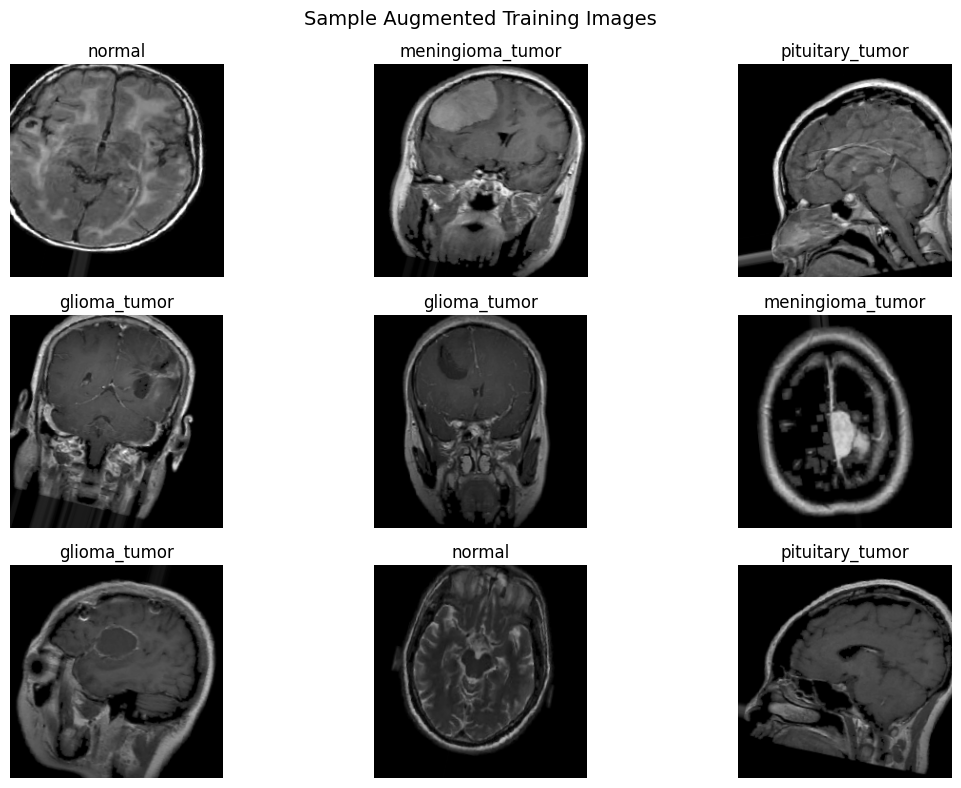

In [17]:
# ============================================================
# 15. VISUALIZE AUGMENTED IMAGES
# ============================================================

images, labels = next(train_gen_cnn)

plt.figure(figsize=(12, 8))

for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(idx_to_class[np.argmax(labels[i])])
    plt.axis("off")

plt.suptitle("Sample Augmented Training Images", fontsize=14)
plt.tight_layout()
plt.show()

## Handling Class Imbalance

The dataset has class imbalance, especially because the normal class has fewer images. To reduce bias toward majority classes, class weights are calculated using the balanced method from scikit-learn and passed to the model during training.

In [18]:
# ============================================================
# 16. CLASS WEIGHTS FOR CLASS IMBALANCE
# ============================================================

train_labels = train_gen_cnn.classes

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {
    int(i): float(w)
    for i, w in zip(np.unique(train_labels), class_weights_array)
}

print("Class weights:")

for idx, weight in class_weights.items():
    print(f"{idx_to_class[idx]}: {weight:.4f}")

Class weights:
glioma_tumor: 0.8575
meningioma_tumor: 0.8463
normal: 1.7825
pituitary_tumor: 0.9164


## Helper Functions

The following helper functions are used for callbacks, plotting training curves, evaluating models, calculating ROC-AUC, and storing final comparison results.

In [19]:
# ============================================================
# 17. CALLBACK FUNCTION
# ============================================================

RESULTS = []

def make_callbacks(model_name):
    os.makedirs("/content/models", exist_ok=True)
    checkpoint_path = f"/content/models/{model_name}.keras"

    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

In [20]:
# ============================================================
# 18. TRAINING CURVE PLOT FUNCTION
# ============================================================

def plot_training_curves(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{title}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title}: Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [21]:
# ============================================================
# 19. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, generator, model_name):
    generator.reset()

    y_true = generator.classes
    y_prob = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n===== {model_name} Evaluation =====")
    print("Accuracy:", round(acc, 4))
    print("Weighted Precision:", round(precision, 4))
    print("Weighted Recall:", round(recall, 4))
    print("Weighted F1-score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[idx_to_class[i] for i in range(num_classes)],
        zero_division=0
    ))

    return y_true, y_pred, y_prob, {
        "Model": model_name,
        "Accuracy": acc,
        "Weighted Precision": precision,
        "Weighted Recall": recall,
        "Weighted F1": f1
    }

In [22]:
# ============================================================
# 20. CONFUSION MATRIX FUNCTION
# ============================================================

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        range(num_classes),
        [idx_to_class[i] for i in range(num_classes)],
        rotation=45
    )

    plt.yticks(
        range(num_classes),
        [idx_to_class[i] for i in range(num_classes)]
    )

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [23]:
# ============================================================
# 21. ROC-AUC FUNCTION
# ============================================================

def plot_roc_auc(y_true, y_prob, model_name):
    try:
        y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

        roc_auc_weighted = roc_auc_score(
            y_true_bin,
            y_prob,
            average="weighted",
            multi_class="ovr"
        )

        roc_auc_macro = roc_auc_score(
            y_true_bin,
            y_prob,
            average="macro",
            multi_class="ovr"
        )

        print("Weighted ROC-AUC:", round(roc_auc_weighted, 4))
        print("Macro ROC-AUC:", round(roc_auc_macro, 4))

        plt.figure(figsize=(8, 6))

        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            class_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{idx_to_class[i]} AUC={class_auc:.3f}")

        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.title(f"{model_name} ROC Curves")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        return roc_auc_weighted, roc_auc_macro

    except Exception as e:
        print("ROC-AUC could not be calculated:", e)
        return np.nan, np.nan

In [24]:
# ============================================================
# 22. ADD RESULT FUNCTION
# ============================================================

def add_result(metrics, roc_auc_weighted, roc_auc_macro, training_time_seconds, notes):
    row = dict(metrics)
    row["Weighted ROC-AUC"] = roc_auc_weighted
    row["Macro ROC-AUC"] = roc_auc_macro
    row["Training Time Seconds"] = training_time_seconds
    row["Training Time Minutes"] = training_time_seconds / 60
    row["Notes"] = notes
    RESULTS.append(row)

## Baseline CNN Model

The baseline CNN follows the assessment requirement. It contains three convolutional layers, each followed by max-pooling, three fully connected layers, and one softmax output layer for four-class classification.

In [25]:
# ============================================================
# 23. BUILD BASELINE CNN
# ============================================================

def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential(name="Baseline_CNN")

    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(64, activation="relu"))

    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

baseline_model = build_baseline_cnn(num_classes=num_classes)

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,825,028 (98.51 MB)

 Trainable params: 25,825,028 (98.51 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ============================================================
# 24. TRAIN BASELINE CNN
# ============================================================

EPOCHS_BASELINE = 20

start_time = time.time()

baseline_history = baseline_model.fit(
    train_gen_cnn,
    validation_data=val_gen_cnn,
    epochs=EPOCHS_BASELINE,
    class_weight=class_weights,
    callbacks=make_callbacks("baseline_cnn"),
    verbose=1
)

baseline_time = time.time() - start_time

print("Baseline CNN training time seconds:", round(baseline_time, 2))
print("Baseline CNN training time minutes:", round(baseline_time / 60, 2))

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.2220 - loss: 1.4449
Epoch 1: val_loss improved from None to 1.22349, saving model to /content/models/baseline_cnn.keras

Epoch 1: finished saving model to /content/models/baseline_cnn.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 679ms/step - accuracy: 0.2618 - loss: 1.3794 - val_accuracy: 0.4274 - val_loss: 1.2235 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.3106 - loss: 1.3318
Epoch 2: val_loss improved from 1.22349 to 1.08852, saving model to /content/models/baseline_cnn.keras

Epoch 2: finished saving model to /content/models/baseline_cnn.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 620ms/step - accuracy: 0.3525 - loss: 1.2936 - val_accuracy: 0.5863 - val_loss: 1.0885 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.4656 - loss: 1.1273
Epoch 3: val_loss improved from 1.08852 to 1.05111, saving model to /content/models/baseline_cnn.keras

Epoch 3: fi

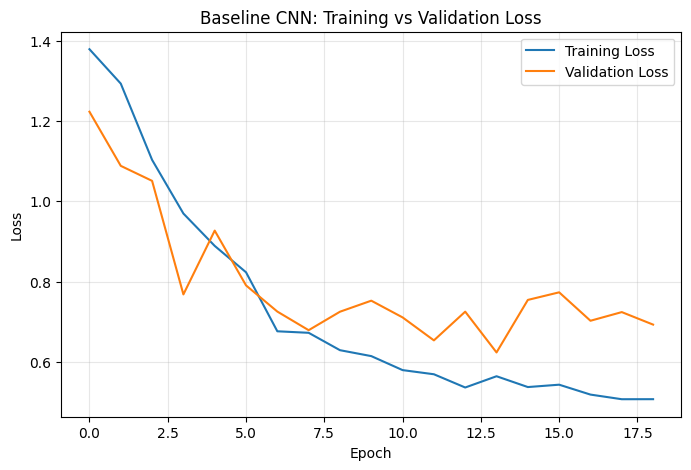

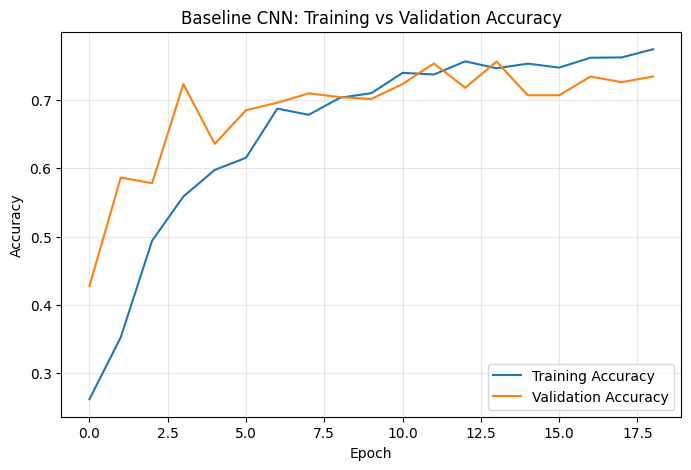

In [27]:
# ============================================================
# 25. BASELINE CNN CURVES
# ============================================================

plot_training_curves(baseline_history, "Baseline CNN")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step

===== Baseline CNN Evaluation =====
Accuracy: 0.7262
Weighted Precision: 0.7423
Weighted Recall: 0.7262
Weighted F1-score: 0.7111

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.78      0.71      0.74       181
meningioma_tumor       0.78      0.44      0.56       183
          normal       0.74      0.88      0.80        88
 pituitary_tumor       0.66      0.98      0.79       169

        accuracy                           0.73       621
       macro avg       0.74      0.75      0.72       621
    weighted avg       0.74      0.73      0.71       621



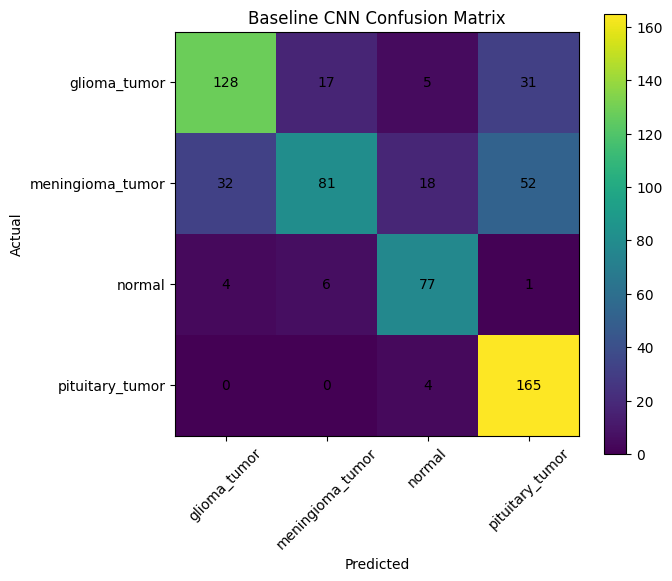

Weighted ROC-AUC: 0.9255
Macro ROC-AUC: 0.9323


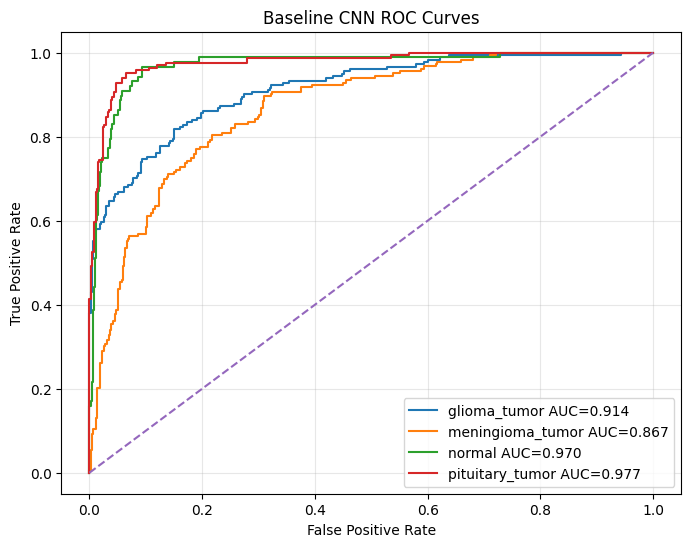

In [28]:
# ============================================================
# 26. BASELINE CNN EVALUATION
# ============================================================

baseline_y_true, baseline_y_pred, baseline_y_prob, baseline_metrics = evaluate_model(
    baseline_model,
    test_gen_cnn,
    "Baseline CNN"
)

plot_confusion_matrix(baseline_y_true, baseline_y_pred, "Baseline CNN")

baseline_roc_weighted, baseline_roc_macro = plot_roc_auc(
    baseline_y_true,
    baseline_y_prob,
    "Baseline CNN"
)

add_result(
    baseline_metrics,
    baseline_roc_weighted,
    baseline_roc_macro,
    baseline_time,
    "Baseline from scratch: 3 Conv+Pool layers, 3 FC layers, Adam optimizer."
)

## Deeper CNN with Regularization

The deeper CNN doubles the convolutional depth compared to the baseline model. It uses six convolutional layers, batch normalization, dropout, and L2 regularization to improve generalization and reduce overfitting.

In [29]:
# ============================================================
# 27. BUILD DEEPER CNN WITH REGULARIZATION
# ============================================================

def build_deeper_cnn(input_shape=(224, 224, 3), num_classes=4, dropout=True, batchnorm=True):
    model = models.Sequential(name="Deeper_Regularized_CNN")

    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4)))
    if batchnorm:
        model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4)))
    if batchnorm:
        model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D((2, 2)))
    if dropout:
        model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4)))
    if batchnorm:
        model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4)))
    if batchnorm:
        model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D((2, 2)))
    if dropout:
        model.add(layers.Dropout(0.30))

    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4)))
    if batchnorm:
        model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4)))
    if batchnorm:
        model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D((2, 2)))
    if dropout:
        model.add(layers.Dropout(0.40))

    model.add(layers.Flatten())

    model.add(layers.Dense(512, activation="relu",
                           kernel_regularizer=regularizers.l2(1e-4)))
    if batchnorm:
        model.add(layers.BatchNormalization())
    if dropout:
        model.add(layers.Dropout(0.50))

    model.add(layers.Dense(256, activation="relu",
                           kernel_regularizer=regularizers.l2(1e-4)))
    if batchnorm:
        model.add(layers.BatchNormalization())
    if dropout:
        model.add(layers.Dropout(0.40))

    model.add(layers.Dense(128, activation="relu",
                           kernel_regularizer=regularizers.l2(1e-4)))
    if dropout:
        model.add(layers.Dropout(0.30))

    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

In [30]:
# ============================================================
# 28. COMPILE DEEPER CNN WITH ADAM
# ============================================================

deeper_adam_model = build_deeper_cnn(
    num_classes=num_classes,
    dropout=True,
    batchnorm=True
)

deeper_adam_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_adam_model.summary()

Model: "Deeper_Regularized_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 51,837,348 (197.74 MB)

 Trainable params: 51,834,916 (197.73 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [31]:
# ============================================================
# 29. TRAIN DEEPER CNN WITH ADAM
# ============================================================

EPOCHS_DEEPER = 25

start_time = time.time()

deeper_adam_history = deeper_adam_model.fit(
    train_gen_cnn,
    validation_data=val_gen_cnn,
    epochs=EPOCHS_DEEPER,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_cnn_adam"),
    verbose=1
)

deeper_adam_time = time.time() - start_time

print("Deeper CNN Adam training time seconds:", round(deeper_adam_time, 2))
print("Deeper CNN Adam training time minutes:", round(deeper_adam_time / 60, 2))

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.2841 - loss: 2.3271
Epoch 1: val_loss improved from None to 2.27941, saving model to /content/models/deeper_cnn_adam.keras

Epoch 1: finished saving model to /content/models/deeper_cnn_adam.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.3136 - loss: 2.1390 - val_accuracy: 0.2959 - val_loss: 2.2794 - learning_rate: 1.0000e-04
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.3770 - loss: 1.8536
Epoch 2: val_loss did not improve from 2.27941
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 624ms/step - accuracy: 0.3852 - loss: 1.8295 - val_accuracy: 0.2904 - val_loss: 2.8644 - learning_rate: 1.0000e-04
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.3993 - loss: 1.7394
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.

Epoch 3: val_loss did not improve from 2.27941
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 606ms/step - accuracy: 0.4020 - loss: 1.7327 - val_accuracy: 0.3699 - val

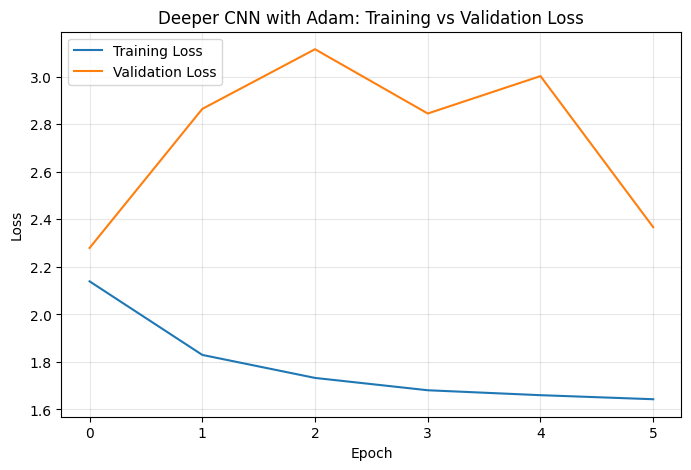

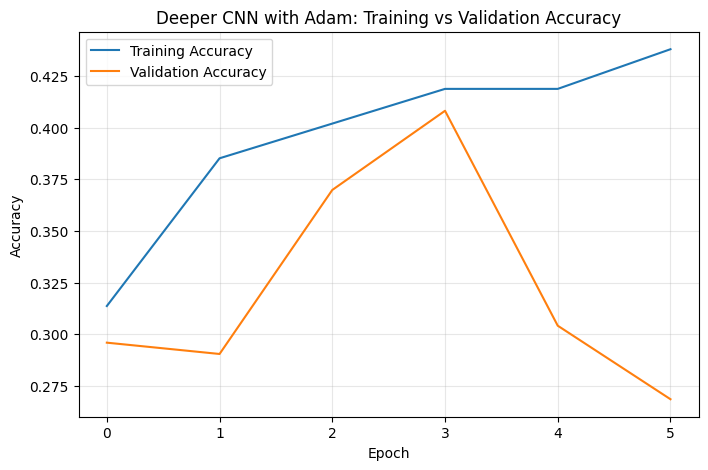

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 459ms/step

===== Deeper CNN Adam Evaluation =====
Accuracy: 0.2947
Weighted Precision: 0.0868
Weighted Recall: 0.2947
Weighted F1-score: 0.1341

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.00      0.00      0.00       181
meningioma_tumor       0.29      1.00      0.46       183
          normal       0.00      0.00      0.00        88
 pituitary_tumor       0.00      0.00      0.00       169

        accuracy                           0.29       621
       macro avg       0.07      0.25      0.11       621
    weighted avg       0.09      0.29      0.13       621



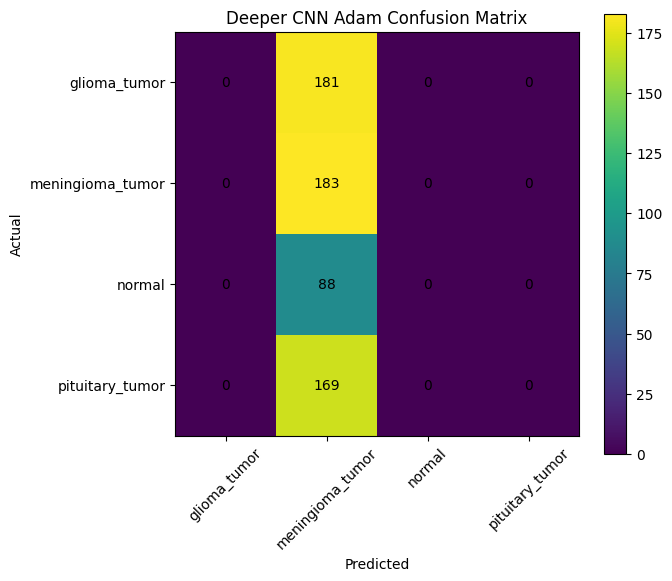

Weighted ROC-AUC: 0.4961
Macro ROC-AUC: 0.4806


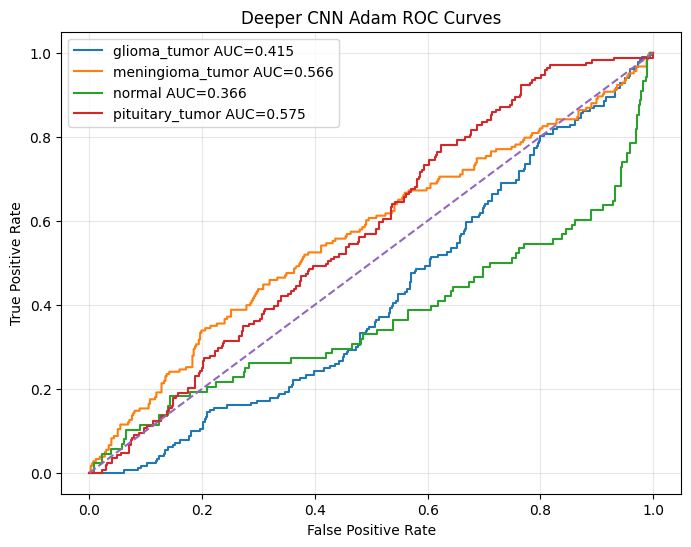

In [32]:
# ============================================================
# 30. DEEPER CNN ADAM EVALUATION
# ============================================================

plot_training_curves(deeper_adam_history, "Deeper CNN with Adam")

adam_y_true, adam_y_pred, adam_y_prob, adam_metrics = evaluate_model(
    deeper_adam_model,
    test_gen_cnn,
    "Deeper CNN Adam"
)

plot_confusion_matrix(adam_y_true, adam_y_pred, "Deeper CNN Adam")

adam_roc_weighted, adam_roc_macro = plot_roc_auc(
    adam_y_true,
    adam_y_prob,
    "Deeper CNN Adam"
)

add_result(
    adam_metrics,
    adam_roc_weighted,
    adam_roc_macro,
    deeper_adam_time,
    "Deeper regularized CNN: 6 Conv layers, BatchNorm, Dropout, L2, Adam optimizer."
)

## Optimizer Comparison: Adam vs SGD

The deeper CNN is trained with both Adam and SGD optimizers. This experiment compares convergence speed, final performance, and computational cost.

In [33]:
# ============================================================
# 31. TRAIN DEEPER CNN WITH SGD
# ============================================================

deeper_sgd_model = build_deeper_cnn(
    num_classes=num_classes,
    dropout=True,
    batchnorm=True
)

deeper_sgd_model.compile(
    optimizer=SGD(learning_rate=1e-3, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_sgd_model.summary()

start_time = time.time()

deeper_sgd_history = deeper_sgd_model.fit(
    train_gen_cnn,
    validation_data=val_gen_cnn,
    epochs=EPOCHS_DEEPER,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_cnn_sgd"),
    verbose=1
)

deeper_sgd_time = time.time() - start_time

print("Deeper CNN SGD training time seconds:", round(deeper_sgd_time, 2))
print("Deeper CNN SGD training time minutes:", round(deeper_sgd_time / 60, 2))

Model: "Deeper_Regularized_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 51,837,348 (197.74 MB)

 Trainable params: 51,834,916 (197.73 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.2809 - loss: 2.0986
Epoch 1: val_loss improved from None to 1.49938, saving model to /content/models/deeper_cnn_sgd.keras

Epoch 1: finished saving model to /content/models/deeper_cnn_sgd.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 72s 906ms/step - accuracy: 0.3242 - loss: 1.9291 - val_accuracy: 0.3041 - val_loss: 1.4994 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.3825 - loss: 1.7201
Epoch 2: val_loss did not improve from 1.49938
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 620ms/step - accuracy: 0.3823 - loss: 1.7026 - val_accuracy: 0.4082 - val_loss: 1.5407 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.3932 - loss: 1.7274
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 3: val_loss did not improve from 1.49938
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 610ms/step - accuracy: 0.3924 - loss: 1.7175 - val_accuracy: 0.3644 - val_loss: 1.

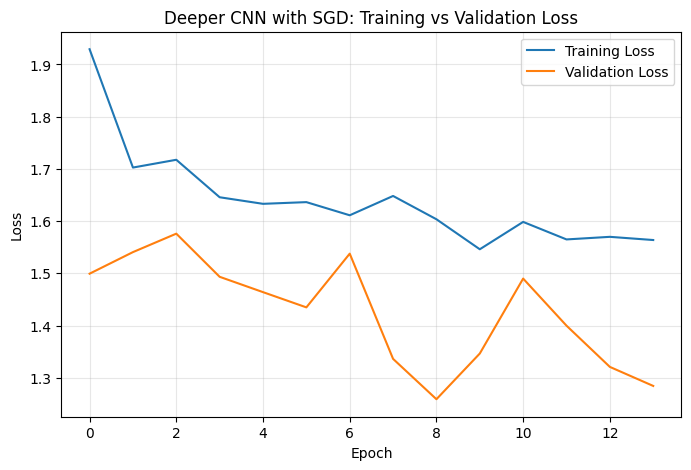

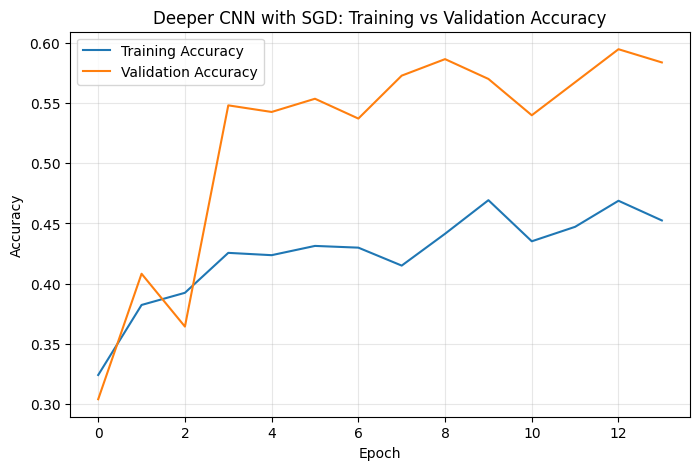

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step

===== Deeper CNN SGD Evaluation =====
Accuracy: 0.5395
Weighted Precision: 0.6224
Weighted Recall: 0.5395
Weighted F1-score: 0.5039

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.78      0.52      0.62       181
meningioma_tumor       0.69      0.17      0.27       183
          normal       0.50      0.60      0.54        88
 pituitary_tumor       0.45      0.93      0.61       169

        accuracy                           0.54       621
       macro avg       0.60      0.56      0.51       621
    weighted avg       0.62      0.54      0.50       621



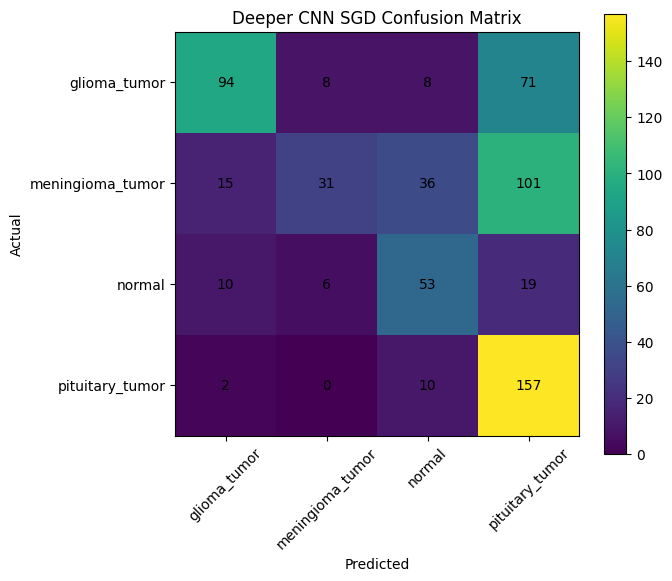

Weighted ROC-AUC: 0.8332
Macro ROC-AUC: 0.8412


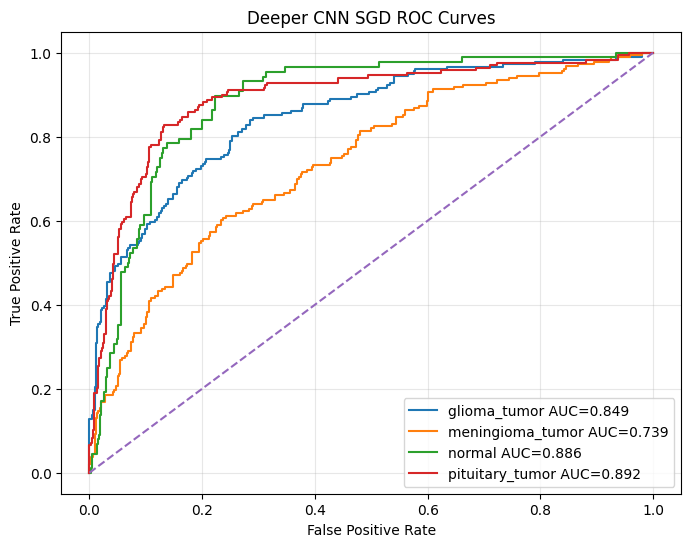

In [34]:
# ============================================================
# 32. DEEPER CNN SGD EVALUATION
# ============================================================

plot_training_curves(deeper_sgd_history, "Deeper CNN with SGD")

sgd_y_true, sgd_y_pred, sgd_y_prob, sgd_metrics = evaluate_model(
    deeper_sgd_model,
    test_gen_cnn,
    "Deeper CNN SGD"
)

plot_confusion_matrix(sgd_y_true, sgd_y_pred, "Deeper CNN SGD")

sgd_roc_weighted, sgd_roc_macro = plot_roc_auc(
    sgd_y_true,
    sgd_y_prob,
    "Deeper CNN SGD"
)

add_result(
    sgd_metrics,
    sgd_roc_weighted,
    sgd_roc_macro,
    deeper_sgd_time,
    "Optimizer comparison: same deeper CNN trained with SGD + momentum."
)

## Ablation Study: Removing Dropout

An ablation study is performed by removing dropout from the deeper CNN. This helps analyze whether dropout improves generalization and reduces overfitting.

In [35]:
# ============================================================
# 33. ABLATION STUDY WITHOUT DROPOUT
# ============================================================

ablation_no_dropout_model = build_deeper_cnn(
    num_classes=num_classes,
    dropout=False,
    batchnorm=True
)

ablation_no_dropout_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ablation_no_dropout_model.summary()

start_time = time.time()

ablation_history = ablation_no_dropout_model.fit(
    train_gen_cnn,
    validation_data=val_gen_cnn,
    epochs=EPOCHS_DEEPER,
    class_weight=class_weights,
    callbacks=make_callbacks("ablation_no_dropout"),
    verbose=1
)

ablation_time = time.time() - start_time

print("Ablation no-dropout training time seconds:", round(ablation_time, 2))
print("Ablation no-dropout training time minutes:", round(ablation_time / 60, 2))

Model: "Deeper_Regularized_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,89

 Total params: 51,837,348 (197.74 MB)

 Trainable params: 51,834,916 (197.73 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.4060 - loss: 1.5862
Epoch 1: val_loss improved from None to 4.36957, saving model to /content/models/ablation_no_dropout.keras

Epoch 1: finished saving model to /content/models/ablation_no_dropout.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 75s 966ms/step - accuracy: 0.4789 - loss: 1.3934 - val_accuracy: 0.1397 - val_loss: 4.3696 - learning_rate: 1.0000e-04
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.5417 - loss: 1.1955
Epoch 2: val_loss did not improve from 4.36957
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 642ms/step - accuracy: 0.5672 - loss: 1.1663 - val_accuracy: 0.1397 - val_loss: 4.9975 - learning_rate: 1.0000e-04
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.6087 - loss: 1.0899
Epoch 3: val_loss improved from 4.36957 to 3.17155, saving model to /content/models/ablation_no_dropout.keras

Epoch 3: finished saving model to /content/models/ablation_no_dropout.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 54s 8

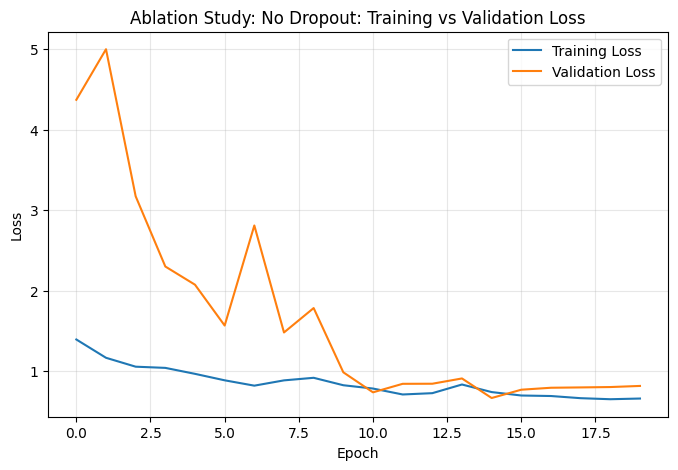

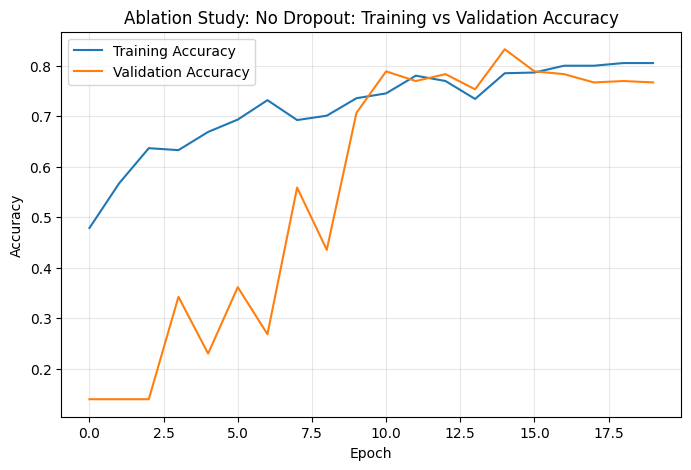

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step

===== Ablation No Dropout Evaluation =====
Accuracy: 0.8035
Weighted Precision: 0.803
Weighted Recall: 0.8035
Weighted F1-score: 0.7974

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.81      0.82      0.82       181
meningioma_tumor       0.78      0.60      0.67       183
          normal       0.74      0.95      0.84        88
 pituitary_tumor       0.85      0.93      0.89       169

        accuracy                           0.80       621
       macro avg       0.80      0.83      0.80       621
    weighted avg       0.80      0.80      0.80       621



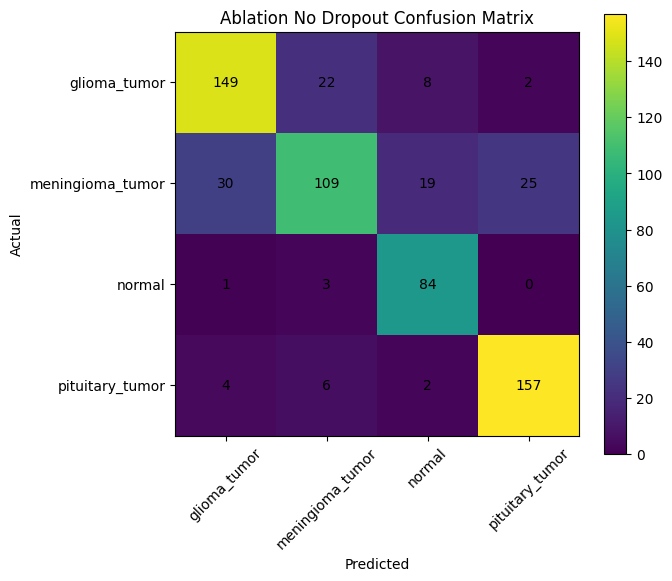

Weighted ROC-AUC: 0.9531
Macro ROC-AUC: 0.9581


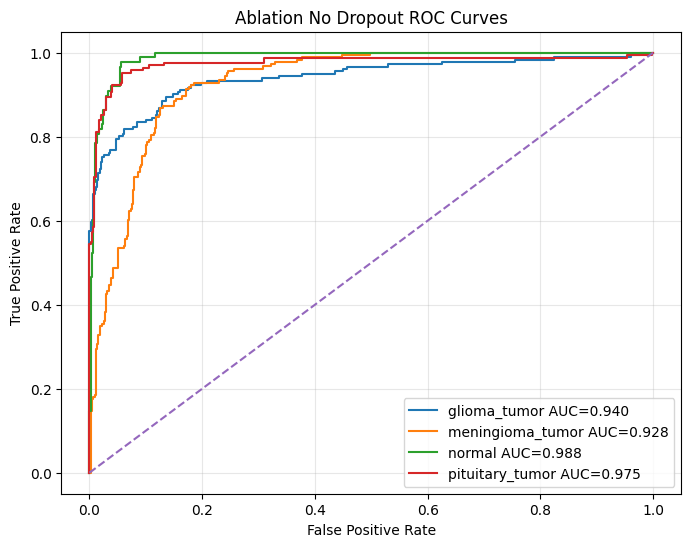

In [36]:
# ============================================================
# 34. ABLATION STUDY EVALUATION
# ============================================================

plot_training_curves(ablation_history, "Ablation Study: No Dropout")

ablation_y_true, ablation_y_pred, ablation_y_prob, ablation_metrics = evaluate_model(
    ablation_no_dropout_model,
    test_gen_cnn,
    "Ablation No Dropout"
)

plot_confusion_matrix(ablation_y_true, ablation_y_pred, "Ablation No Dropout")

ablation_roc_weighted, ablation_roc_macro = plot_roc_auc(
    ablation_y_true,
    ablation_y_prob,
    "Ablation No Dropout"
)

add_result(
    ablation_metrics,
    ablation_roc_weighted,
    ablation_roc_macro,
    ablation_time,
    "Ablation study: dropout removed from deeper CNN."
)

## Transfer Learning Using EfficientNetB3

EfficientNetB3 pretrained on ImageNet is used as the transfer learning model. In Phase 1, the base model is frozen and only the custom classification head is trained. In Phase 2, the top 40% of the base model is unfrozen and fine-tuned using a lower learning rate.

In [37]:
# ============================================================
# 35. DATA GENERATORS FOR EFFICIENTNETB3
# ============================================================
# EfficientNet models in Keras expect input images in the original 0-255 range.
# Therefore, rescale=1/255 is not used here.

train_datagen_eff = ImageDataGenerator(
    validation_split=0.15,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode="nearest"
)

val_datagen_eff = ImageDataGenerator(
    validation_split=0.15
)

test_datagen_eff = ImageDataGenerator()

train_gen_eff = train_datagen_eff.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_gen_eff = val_datagen_eff.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

test_gen_eff = test_datagen_eff.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2082 images belonging to 4 classes.
Found 365 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


In [38]:
# ============================================================
# 36. BUILD EFFICIENTNETB3 TRANSFER LEARNING MODEL
# ============================================================

base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.BatchNormalization(name="transfer_batch_norm")(x)
x = layers.Dense(256, activation="relu", name="transfer_dense_256")(x)
x = layers.Dropout(0.4, name="transfer_dropout")(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax",
    name="transfer_output"
)(x)

efficientnet_model = models.Model(
    inputs,
    outputs,
    name="EfficientNetB3_Transfer_Learning"
)

efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB3_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_batch_norm             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dense_256 (Dense)      │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dropout (Dropout)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_output (Dense)         │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 397,572 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [39]:
# ============================================================
# 37. PHASE 1: FEATURE EXTRACTION
# ============================================================

EPOCHS_FEATURE_EXTRACTION = 15

start_time = time.time()

feature_history = efficientnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=EPOCHS_FEATURE_EXTRACTION,
    class_weight=class_weights,
    callbacks=make_callbacks("efficientnetb3_feature_extraction"),
    verbose=1
)

feature_time = time.time() - start_time

print("Feature extraction training time seconds:", round(feature_time, 2))
print("Feature extraction training time minutes:", round(feature_time / 60, 2))

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.5856 - loss: 1.2228
Epoch 1: val_loss improved from None to 0.58349, saving model to /content/models/efficientnetb3_feature_extraction.keras

Epoch 1: finished saving model to /content/models/efficientnetb3_feature_extraction.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6590 - loss: 0.9839 - val_accuracy: 0.7890 - val_loss: 0.5835 - learning_rate: 0.0010
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.7395 - loss: 0.7584
Epoch 2: val_loss improved from 0.58349 to 0.47558, saving model to /content/models/efficientnetb3_feature_extraction.keras

Epoch 2: finished saving model to /content/models/efficientnetb3_feature_extraction.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 630ms/step - accuracy: 0.7603 - loss: 0.6635 - val_accuracy: 0.8466 - val_loss: 0.4756 - learning_rate: 0.0010
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.7954 - loss: 0.5636
Epoch 3: val_loss improved from 0

In [40]:
# ============================================================
# 38. PHASE 2: FINE-TUNING TOP 40% LAYERS
# ============================================================

base_model.trainable = True

total_layers = len(base_model.layers)
fine_tune_at = int(total_layers * 0.60)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print("Total EfficientNetB3 layers:", total_layers)
print("Frozen layers:", fine_tune_at)
print("Trainable top layers:", total_layers - fine_tune_at)

efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS_FINE_TUNE = 20

start_time = time.time()

fine_tune_history = efficientnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=make_callbacks("efficientnetb3_fine_tuned"),
    verbose=1
)

fine_tune_time = time.time() - start_time
efficientnet_total_time = feature_time + fine_tune_time

print("Fine-tuning training time seconds:", round(fine_tune_time, 2))
print("Fine-tuning training time minutes:", round(fine_tune_time / 60, 2))
print("Total EfficientNetB3 training time seconds:", round(efficientnet_total_time, 2))
print("Total EfficientNetB3 training time minutes:", round(efficientnet_total_time / 60, 2))

Total EfficientNetB3 layers: 385
Frozen layers: 231
Trainable top layers: 154
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7024 - loss: 0.7970
Epoch 1: val_loss improved from None to 0.43433, saving model to /content/models/efficientnetb3_fine_tuned.keras

Epoch 1: finished saving model to /content/models/efficientnetb3_fine_tuned.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.7113 - loss: 0.7432 - val_accuracy: 0.8521 - val_loss: 0.4343 - learning_rate: 1.0000e-05
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.7445 - loss: 0.6021
Epoch 2: val_loss did not improve from 0.43433
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 613ms/step - accuracy: 0.7454 - loss: 0.5987 - val_accuracy: 0.8247 - val_loss: 0.4898 - learning_rate: 1.0000e-05
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.7686 - loss: 0.5901
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_loss did not improve from 0.43433
66/66 ━━━

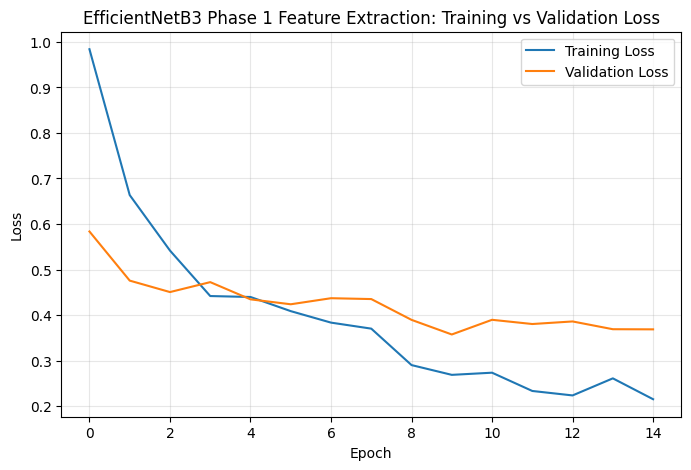

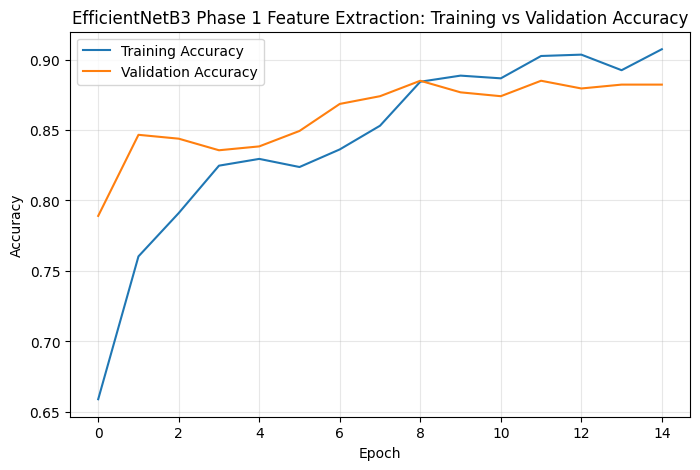

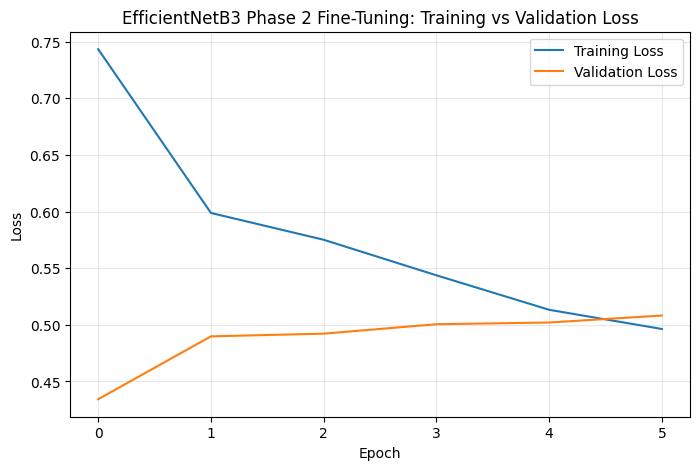

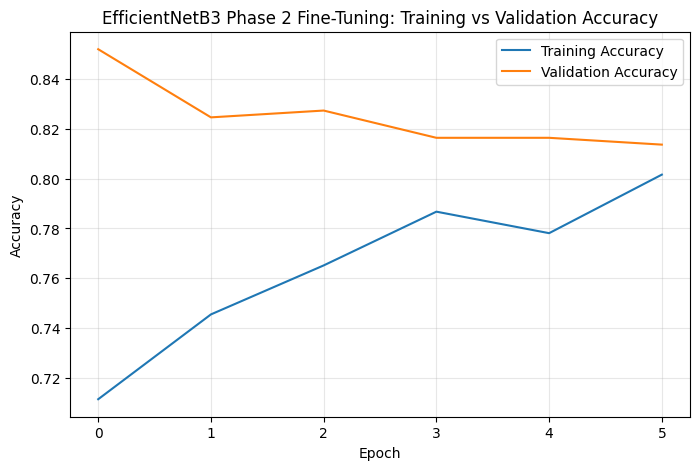

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 715ms/step

===== EfficientNetB3 Fine-Tuned Evaluation =====
Accuracy: 0.8277
Weighted Precision: 0.8302
Weighted Recall: 0.8277
Weighted F1-score: 0.8262

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.86      0.76      0.80       181
meningioma_tumor       0.76      0.75      0.75       183
          normal       0.95      0.88      0.91        88
 pituitary_tumor       0.82      0.96      0.89       169

        accuracy                           0.83       621
       macro avg       0.85      0.84      0.84       621
    weighted avg       0.83      0.83      0.83       621



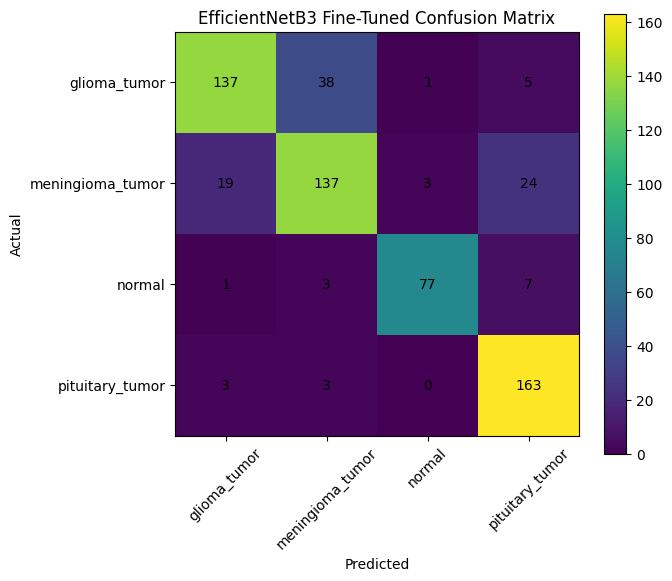

Weighted ROC-AUC: 0.9602
Macro ROC-AUC: 0.9648


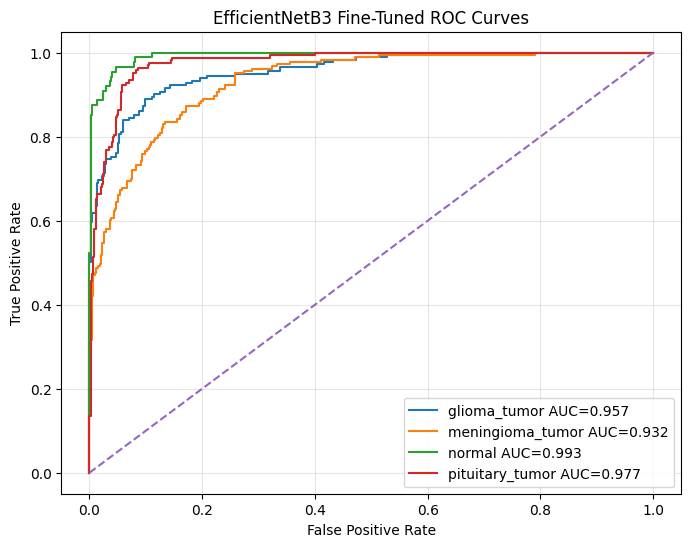

In [41]:
# ============================================================
# 39. EFFICIENTNETB3 EVALUATION
# ============================================================

plot_training_curves(feature_history, "EfficientNetB3 Phase 1 Feature Extraction")
plot_training_curves(fine_tune_history, "EfficientNetB3 Phase 2 Fine-Tuning")

eff_y_true, eff_y_pred, eff_y_prob, eff_metrics = evaluate_model(
    efficientnet_model,
    test_gen_eff,
    "EfficientNetB3 Fine-Tuned"
)

plot_confusion_matrix(eff_y_true, eff_y_pred, "EfficientNetB3 Fine-Tuned")

eff_roc_weighted, eff_roc_macro = plot_roc_auc(
    eff_y_true,
    eff_y_prob,
    "EfficientNetB3 Fine-Tuned"
)

add_result(
    eff_metrics,
    eff_roc_weighted,
    eff_roc_macro,
    efficientnet_total_time,
    "Transfer learning: EfficientNetB3 feature extraction + fine-tuning top 40% layers."
)

## Sample Predictions and Grad-CAM

Sample predictions are displayed to show how the final model performs on unseen test images. Grad-CAM is used to visualize the regions that influenced the EfficientNetB3 model's predictions, supporting interpretability for medical imaging.

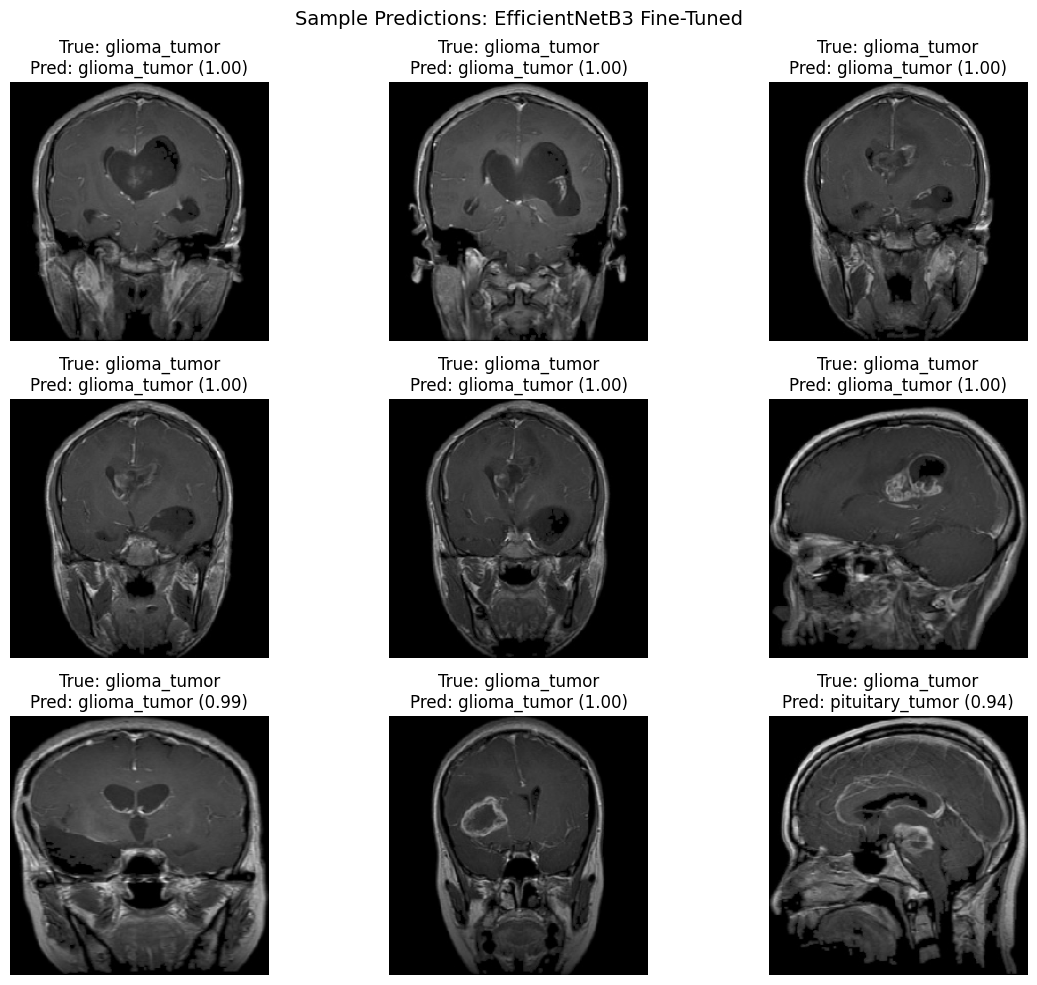

In [42]:
# ============================================================
# 40. SAMPLE PREDICTIONS
# ============================================================

def show_sample_predictions(model, generator, model_name, n=9):
    generator.reset()

    images, labels = next(generator)
    probs = model.predict(images, verbose=0)

    preds = np.argmax(probs, axis=1)
    true_labels = np.argmax(labels, axis=1)

    plt.figure(figsize=(12, 10))

    for i in range(min(n, len(images))):
        plt.subplot(3, 3, i + 1)

        display_img = images[i]

        if display_img.max() > 1:
            display_img = display_img / 255.0

        plt.imshow(display_img)
        plt.title(
            f"True: {idx_to_class[true_labels[i]]}\n"
            f"Pred: {idx_to_class[preds[i]]} ({np.max(probs[i]):.2f})"
        )
        plt.axis("off")

    plt.suptitle(f"Sample Predictions: {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample_predictions(
    efficientnet_model,
    test_gen_eff,
    "EfficientNetB3 Fine-Tuned",
    n=9
)

Last convolutional layer: top_conv


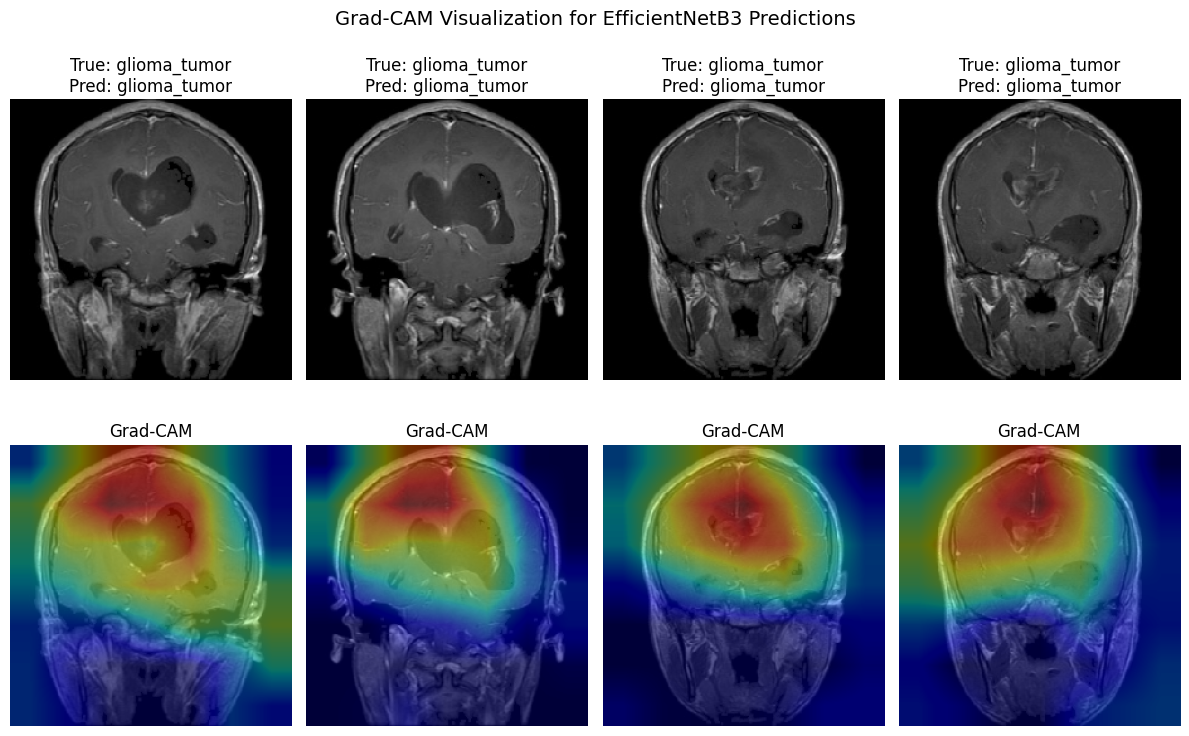

In [44]:
# ============================================================
# 41. GRAD-CAM VISUALIZATION -
# ============================================================

def get_last_conv_layer_name(base_model):
    for layer in reversed(base_model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in base model.")

last_conv_layer_name = get_last_conv_layer_name(base_model)

print("Last convolutional layer:", last_conv_layer_name)


def make_gradcam_heatmap_fixed(img_array, base_model, full_model, last_conv_layer_name, pred_index=None):
    # Model from EfficientNet input to last conv layer + base output
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            base_model.output
        ]
    )

    # Rebuild classifier head using the same trained layers from full model
    classifier_input = layers.Input(shape=base_model.output.shape[1:])
    x = classifier_input

    for layer_name in [
        "global_average_pooling",
        "transfer_batch_norm",
        "transfer_dense_256",
        "transfer_dropout",
        "transfer_output"
    ]:
        x = full_model.get_layer(layer_name)(x)

    classifier_model = tf.keras.models.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = grad_model(img_array)
        predictions = classifier_model(base_outputs)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def show_gradcam_examples_fixed(full_model, base_model, generator, n=4):
    generator.reset()

    images, labels = next(generator)

    plt.figure(figsize=(12, 8))

    for i in range(min(n, len(images))):
        img = images[i]
        img_array = np.expand_dims(img, axis=0)

        preds = full_model.predict(img_array, verbose=0)
        pred_idx = np.argmax(preds[0])
        true_idx = np.argmax(labels[i])

        heatmap = make_gradcam_heatmap_fixed(
            img_array,
            base_model,
            full_model,
            last_conv_layer_name,
            pred_index=pred_idx
        )

        heatmap_resized = tf.image.resize(
            heatmap[..., np.newaxis],
            IMG_SIZE
        ).numpy().squeeze()

        display_img = img.copy()

        if display_img.max() > 1:
            display_img = display_img / 255.0

        plt.subplot(2, n, i + 1)
        plt.imshow(display_img)
        plt.title(
            f"True: {idx_to_class[true_idx]}\n"
            f"Pred: {idx_to_class[pred_idx]}"
        )
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(display_img)
        plt.imshow(heatmap_resized, alpha=0.45, cmap="jet")
        plt.title("Grad-CAM")
        plt.axis("off")

    plt.suptitle("Grad-CAM Visualization for EfficientNetB3 Predictions", fontsize=14)
    plt.tight_layout()
    plt.show()


show_gradcam_examples_fixed(
    efficientnet_model,
    base_model,
    test_gen_eff,
    n=4
)

## Final Model Comparison

All trained models are compared using accuracy, weighted precision, weighted recall, weighted F1-score, ROC-AUC, and training time. This comparison helps identify whether deeper CNNs and transfer learning improved performance compared to the baseline CNN.

In [45]:
# ============================================================
# 42. FINAL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(RESULTS)

results_df = results_df.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Weighted ROC-AUC,Macro ROC-AUC,Training Time Seconds,Training Time Minutes,Notes
0,EfficientNetB3 Fine-Tuned,0.827697,0.830236,0.827697,0.826233,0.960220,0.964830,1077.297378,17.954956,Transfer learning: EfficientNetB3 feature extr...
1,Ablation No Dropout,0.803543,0.803005,0.803543,0.797370,0.953138,0.958094,1040.451646,17.340861,Ablation study: dropout removed from deeper CNN.
2,Baseline CNN,0.726248,0.742253,0.726248,0.711124,0.925530,0.932295,789.984632,13.166411,"Baseline from scratch: 3 Conv+Pool layers, 3 F..."
3,Deeper CNN SGD,0.539452,0.622401,0.539452,0.503892,0.833225,0.841169,670.474703,11.174578,Optimizer comparison: same deeper CNN trained ...
4,Deeper CNN Adam,0.294686,0.086840,0.294686,0.134148,0.496105,0.480574,312.471347,5.207856,"Deeper regularized CNN: 6 Conv layers, BatchNo..."


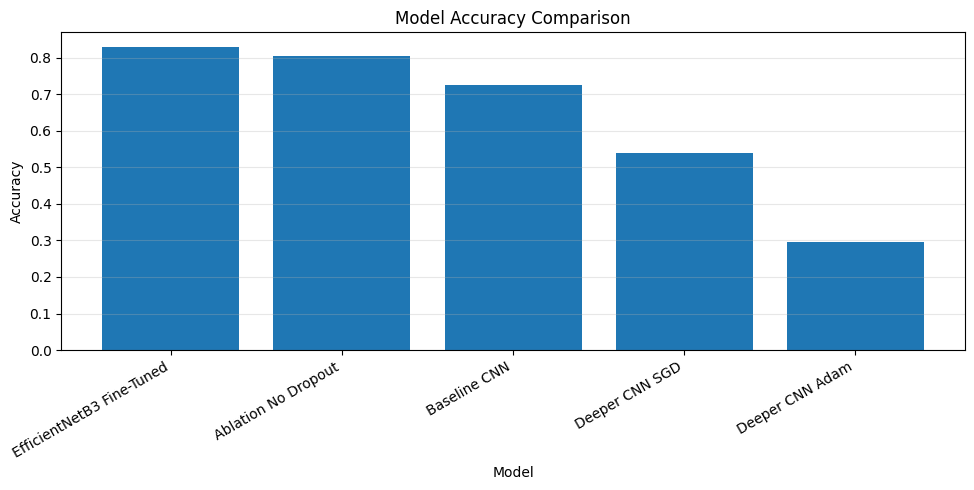

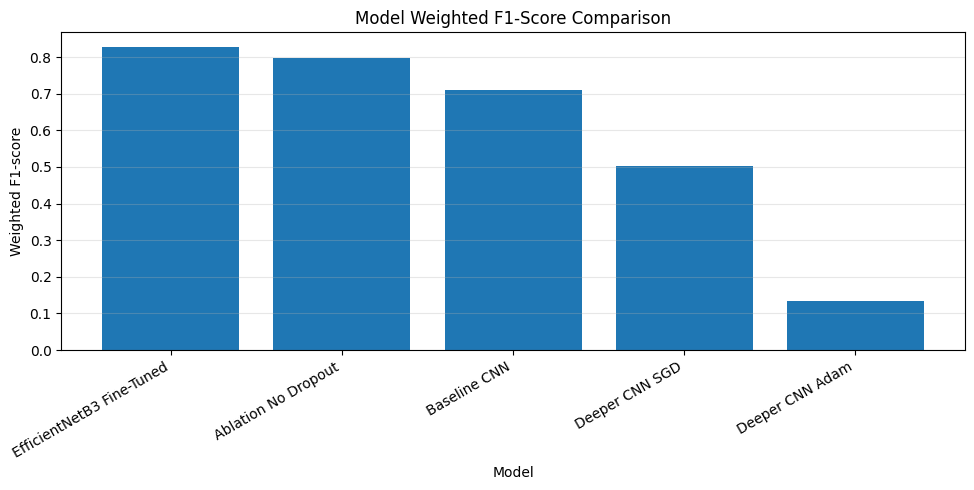

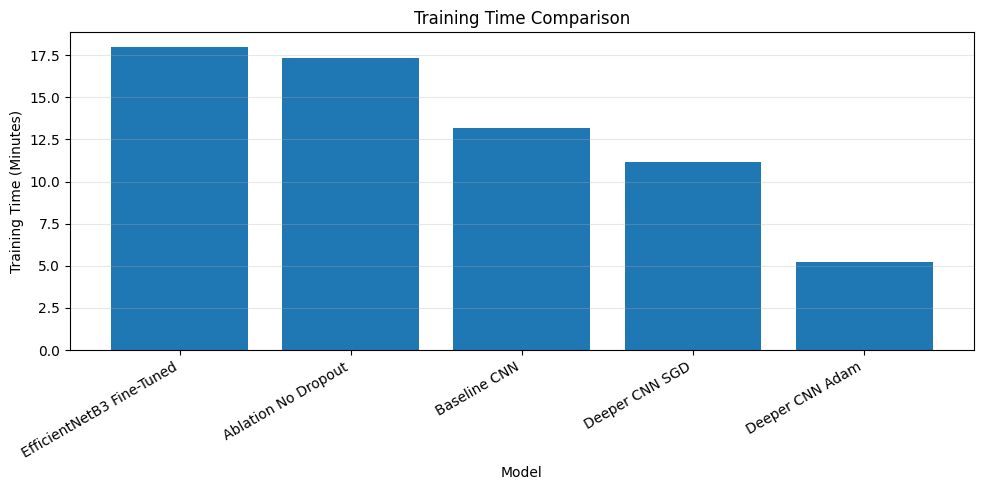

In [46]:
# ============================================================
# 43. FINAL COMPARISON GRAPHS
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Weighted F1"])
plt.title("Model Weighted F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Training Time Minutes"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (Minutes)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# 44. FINAL OBSERVATION SUMMARY
# ============================================================

best_row = results_df.iloc[0]

print("===== FINAL OBSERVATION SUMMARY =====")
print(f"Best performing model: {best_row['Model']}")
print(f"Best accuracy: {best_row['Accuracy']:.4f}")
print(f"Best weighted F1-score: {best_row['Weighted F1']:.4f}")
print(f"Best weighted ROC-AUC: {best_row['Weighted ROC-AUC']:.4f}")
print()

print("Completed assessment checklist:")
print("1. Dataset understanding and class distribution: Completed")
print("2. Corrupted image cleaning: Completed")
print("3. Preprocessing and augmentation: Completed")
print("4. Augmented image visualization: Completed")
print("5. Baseline CNN with 3 Conv+Pool layers and 3 FC layers: Completed")
print("6. Deeper CNN with double Conv depth and regularization: Completed")
print("7. Adam vs SGD optimizer comparison: Completed")
print("8. Ablation study by removing dropout: Completed")
print("9. Transfer learning using EfficientNetB3: Completed")
print("10. Feature extraction and fine-tuning: Completed")
print("11. Accuracy, precision, recall, F1-score, confusion matrix: Completed")
print("12. ROC-AUC evaluation: Completed")
print("13. Sample predictions: Completed")
print("14. Grad-CAM visualization: Completed")
print("15. Training time comparison: Completed")

===== FINAL OBSERVATION SUMMARY =====
Best performing model: EfficientNetB3 Fine-Tuned
Best accuracy: 0.8277
Best weighted F1-score: 0.8262
Best weighted ROC-AUC: 0.9602

Completed assessment checklist:
1. Dataset understanding and class distribution: Completed
2. Corrupted image cleaning: Completed
3. Preprocessing and augmentation: Completed
4. Augmented image visualization: Completed
5. Baseline CNN with 3 Conv+Pool layers and 3 FC layers: Completed
6. Deeper CNN with double Conv depth and regularization: Completed
7. Adam vs SGD optimizer comparison: Completed
8. Ablation study by removing dropout: Completed
9. Transfer learning using EfficientNetB3: Completed
10. Feature extraction and fine-tuning: Completed
11. Accuracy, precision, recall, F1-score, confusion matrix: Completed
12. ROC-AUC evaluation: Completed
13. Sample predictions: Completed
14. Grad-CAM visualization: Completed
15. Training time comparison: Completed


In [48]:
# ============================================================
# 45. SAVE MODELS AND RESULTS
# ============================================================

os.makedirs("/content/final_task2_outputs", exist_ok=True)

baseline_model.save("/content/final_task2_outputs/baseline_cnn.keras")
deeper_adam_model.save("/content/final_task2_outputs/deeper_cnn_adam.keras")
deeper_sgd_model.save("/content/final_task2_outputs/deeper_cnn_sgd.keras")
ablation_no_dropout_model.save("/content/final_task2_outputs/ablation_no_dropout.keras")
efficientnet_model.save("/content/final_task2_outputs/efficientnetb3_fine_tuned.keras")

results_df.to_csv(
    "/content/final_task2_outputs/task2_model_comparison_results.csv",
    index=False
)

shutil.make_archive(
    "/content/final_task2_outputs",
    "zip",
    "/content/final_task2_outputs"
)

print("Saved all models and results.")
print("ZIP created: /content/final_task2_outputs.zip")

Saved all models and results.
ZIP created: /content/final_task2_outputs.zip
